# Affect-Aware Music Recommendation — Model Comparison
**Purpose:** Comparative analysis of candidate models for:
1. **Genre Classification** — supervised multiclass prediction from 14 audio features
2. **Similarity / Recommendation** — content-based track retrieval
3. **Intervention Trigger** — detecting anomalous low-mood listening patterns

Run every cell top-to-bottom. Final cells produce summary tables and charts.

---
## 0. Setup & Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Classifiers
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import lightgbm as lgb
import xgboost as xgb

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Recommendation / similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine as cosine_dist

# Anomaly detection (intervention trigger)
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

# Style
plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = ['#7c5dff','#0ed2b7','#ffb347','#ff5c8a','#3dd598','#5a7bff']
sns.set_palette(PALETTE)

SEED = 42
np.random.seed(SEED)
print('All imports OK')

All imports OK


---
## 1. Load & Preprocess Data

Dataset: 114,000 rows | 114 genres
Train: 91,200 | Test: 22,800
Features (all): 14 | Acoustic-only: 12


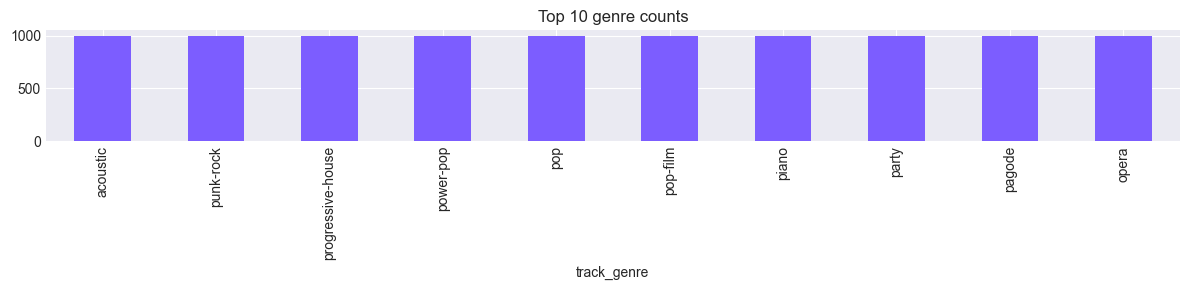

In [ ]:
DATASET_PATH = '../dataset.csv'  # adjust if needed

FEATURE_COLS = [
    'popularity', 'duration_ms', 'danceability', 'energy', 'key',
    'loudness', 'mode', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature'
]

# Acoustic-only features (no metadata) — used for KNN similarity
ACOUSTIC_COLS = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature'
]

df = pd.read_csv(DATASET_PATH, index_col=0)
df = df.dropna(subset=FEATURE_COLS + ['track_genre']).reset_index(drop=True)

# Encode genre labels
le = LabelEncoder()
df['genre_int'] = le.fit_transform(df['track_genre'])
n_genres = df['genre_int'].nunique()

# Scale
scaler_all   = MinMaxScaler()
scaler_acous = MinMaxScaler()

X_all   = scaler_all.fit_transform(df[FEATURE_COLS].values.astype(float))
X_acous = scaler_acous.fit_transform(df[ACOUSTIC_COLS].values.astype(float))
y       = df['genre_int'].values

# Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Dataset: {len(df):,} rows | {n_genres} genres')
print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')
print(f'Features (all): {len(FEATURE_COLS)} | Acoustic-only: {len(ACOUSTIC_COLS)}')
df['track_genre'].value_counts().head(10).plot(
    kind='bar', figsize=(12,3), title='Top 10 genre counts', color=PALETTE[0]
)
plt.tight_layout()
plt.show()

---
## 2. Genre Classification — Model Comparison

We compare 6 models on the same stratified 80/20 split, then run 5-fold CV on the top-2.

| Model | Why it's a candidate |
|---|---|
| Random Forest (baseline) | Current production model |
| LightGBM | Sequential boosting, better on noisy labels |
| XGBoost | Similar to LGBM, different regularisation |
| Logistic Regression | Linear baseline — shows whether problem is linearly separable |
| MLP (Neural Net) | Learns non-linear feature interactions |
| SVM (RBF) | Strong on high-dim spaces, slow on large N — we subsample |

In [4]:
classifiers = {
    'Random Forest (baseline)': RandomForestClassifier(
        n_estimators=100, max_depth=20, min_samples_leaf=2,
        n_jobs=-1, random_state=SEED
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, n_jobs=-1, random_state=SEED, verbose=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        use_label_encoder=False, eval_metric='mlogloss',
        n_jobs=-1, random_state=SEED, verbosity=0
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, n_jobs=-1, random_state=SEED
    ),
    'MLP (Neural Net)': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        max_iter=200, early_stopping=True, random_state=SEED
    ),
    # SVM is O(n^2) — subsample to 15k for feasibility
    'SVM RBF (15k sample)': None  # handled separately below
}

results = {}

for name, clf in classifiers.items():
    if name == 'SVM RBF (15k sample)':
        idx = np.random.choice(len(X_tr), size=15000, replace=False)
        Xs, ys = X_tr[idx], y_tr[idx]
        clf = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED)
        t0 = time.time()
        clf.fit(Xs, ys)
        train_time = time.time() - t0
        y_pred = clf.predict(X_te)
    else:
        t0 = time.time()
        clf.fit(X_tr, y_tr)
        train_time = time.time() - t0
        y_pred = clf.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='macro', zero_division=0)
    results[name] = {
        'model': clf,
        'accuracy': acc,
        'macro_f1': f1,
        'train_time_s': round(train_time, 2),
        'y_pred': y_pred
    }
    print(f"{name:<35} acc={acc:.4f}  f1={f1:.4f}  time={train_time:.1f}s")

Random Forest (baseline)            acc=0.3187  f1=0.3105  time=6.2s
LightGBM                            acc=0.3155  f1=0.3193  time=140.2s
XGBoost                             acc=0.3298  f1=0.3250  time=67.6s
Logistic Regression                 acc=0.1850  f1=0.1536  time=42.3s
MLP (Neural Net)                    acc=0.2898  f1=0.2712  time=529.5s
SVM RBF (15k sample)                acc=0.2128  f1=0.1984  time=47.6s


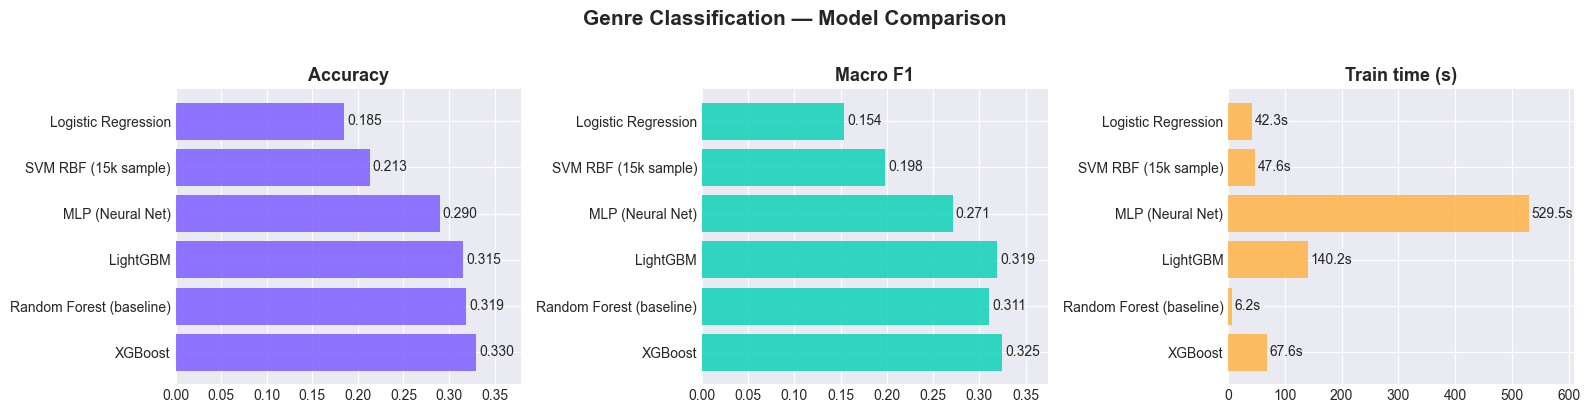

                   Model  Accuracy  Macro F1  Train time (s)
                 XGBoost  0.329781  0.324962           67.64
Random Forest (baseline)  0.318728  0.310501            6.21
                LightGBM  0.315482  0.319303          140.24
        MLP (Neural Net)  0.289781  0.271175          529.55
    SVM RBF (15k sample)  0.212807  0.198424           47.62
     Logistic Regression  0.184956  0.153629           42.32


In [5]:
# Summary bar chart
res_df = pd.DataFrame([
    {'Model': k, 'Accuracy': v['accuracy'], 'Macro F1': v['macro_f1'], 'Train time (s)': v['train_time_s']}
    for k, v in results.items()
]).sort_values('Accuracy', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, ['Accuracy', 'Macro F1', 'Train time (s)'], PALETTE[:3]):
    bars = ax.barh(res_df['Model'], res_df[col], color=color, alpha=0.85)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlim(0, res_df[col].max() * 1.15)
    for bar, val in zip(bars, res_df[col]):
        ax.text(bar.get_width() + res_df[col].max()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}' if col != 'Train time (s)' else f'{val:.1f}s',
                va='center', fontsize=10)
plt.suptitle('Genre Classification — Model Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('genre_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(res_df[['Model','Accuracy','Macro F1','Train time (s)']].to_string(index=False))

### 2a. 5-Fold Cross-Validation on Top Models

XGBoost                             CV acc: 0.3331 ± 0.0022  | folds: [0.3295 0.3343 0.3321 0.3337 0.3359]
Random Forest (baseline)            CV acc: nan ± nan  | folds: [0.3226 0.3176    nan    nan 0.325 ]
LightGBM                            CV acc: 0.3183 ± 0.0014  | folds: [0.3166 0.3169 0.3197 0.3181 0.3201]


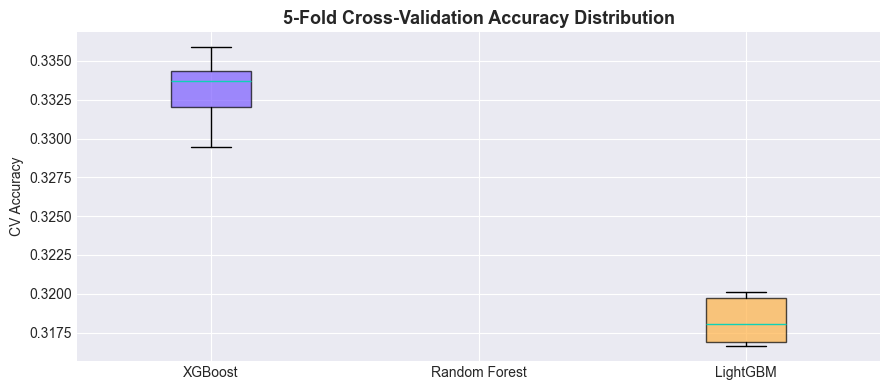

In [6]:
# Pick the top 3 by accuracy for CV (skip SVM — too slow for full CV)
top_names = res_df[~res_df['Model'].str.contains('SVM')]['Model'].head(3).tolist()
cv_results = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name in top_names:
    clf = results[name]['model']
    # Re-clone by re-creating — using clone()
    from sklearn.base import clone
    clf_fresh = clone(clf)
    scores = cross_val_score(clf_fresh, X_all, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<35} CV acc: {scores.mean():.4f} ± {scores.std():.4f}  | folds: {scores.round(4)}")

# Box plot of CV scores
fig, ax = plt.subplots(figsize=(9, 4))
bp = ax.boxplot([cv_results[n] for n in top_names], patch_artist=True, labels=[n.split('(')[0].strip() for n in top_names])
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('CV Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### 2b. Feature Importance Comparison

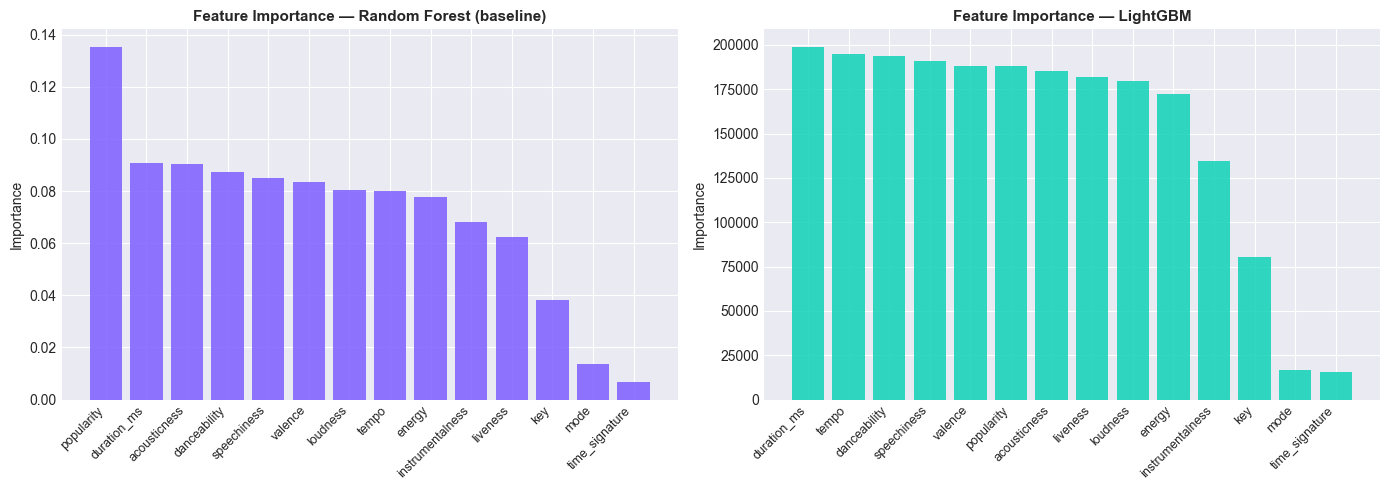

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_models = {
    'Random Forest (baseline)': 'feature_importances_',
    'LightGBM': 'feature_importances_',
}

for ax, (name, attr) in zip(axes, importance_models.items()):
    clf = results[name]['model']
    importances = getattr(clf, attr)
    idx = np.argsort(importances)[::-1]
    ax.bar(range(len(FEATURE_COLS)), importances[idx],
           color=PALETTE[list(importance_models.keys()).index(name)], alpha=0.85)
    ax.set_xticks(range(len(FEATURE_COLS)))
    ax.set_xticklabels([FEATURE_COLS[i] for i in idx], rotation=45, ha='right', fontsize=9)
    ax.set_title(f'Feature Importance — {name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 2c. Confusion Matrix — Best Model vs Baseline

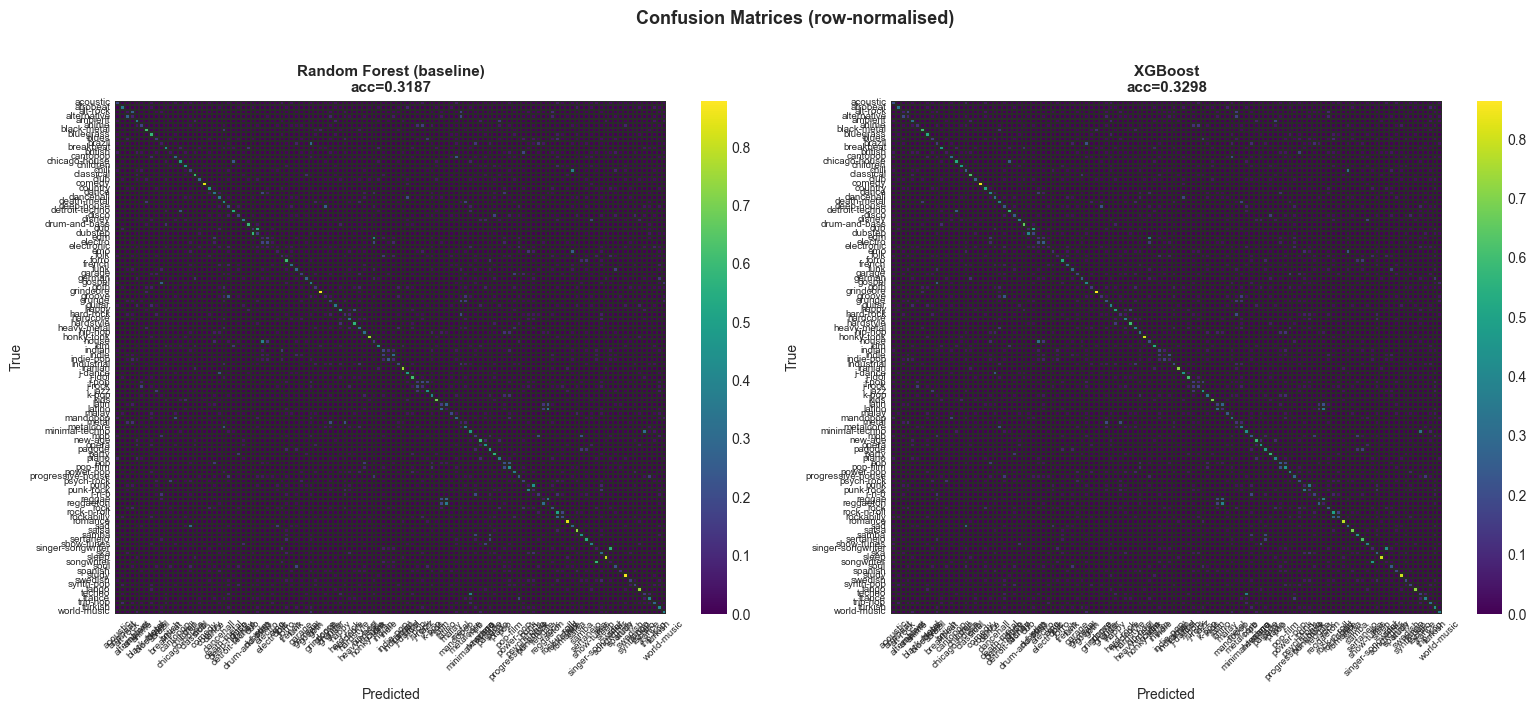

In [8]:
best_model_name = res_df['Model'].iloc[0]
baseline_name   = 'Random Forest (baseline)'

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, name in zip(axes, [baseline_name, best_model_name]):
    cm = confusion_matrix(y_te, results[name]['y_pred'])
    # Normalize so it fits on screen
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, ax=ax, cmap='viridis', xticklabels=le.classes_,
                yticklabels=le.classes_, annot=False, fmt='.2f',
                linewidths=0.3, linecolor='#2a2a2a')
    ax.set_title(f'{name}\nacc={results[name]["accuracy"]:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle('Confusion Matrices (row-normalised)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Similarity / Recommendation — KNN Variants

We compare three approaches for "find tracks like this one":

| Approach | Description |
|---|---|
| KNN-all (baseline) | All 14 features, cosine similarity — current system |
| KNN-acoustic | 12 acoustic features only (drop `popularity`, `duration_ms`) |
| KNN-weighted | 12 acoustic features, valence/energy/danceability weighted 3× |

**Evaluation:** For a set of seed tracks, measure *within-genre hit rate* at K=5 and *valence consistency* (std dev of returned valence). Lower std = recommendations are tonally cohesive.

In [9]:
# Build three KNN indices
def build_knn(X, n=50):
    knn = NearestNeighbors(n_neighbors=min(n, len(X)), metric='cosine', algorithm='auto')
    knn.fit(X)
    return knn

# Weighted features: valence, energy, danceability get 3x weight
WEIGHT_EMPHASIS = ['valence', 'energy', 'danceability']
weights = np.array([3.0 if c in WEIGHT_EMPHASIS else 1.0 for c in ACOUSTIC_COLS])
X_acous_w = X_acous * weights  # re-scale after weighting
X_acous_w = MinMaxScaler().fit_transform(X_acous_w)

knn_all    = build_knn(X_all)
knn_acous  = build_knn(X_acous)
knn_wt     = build_knn(X_acous_w)

print('KNN indices built')

# --- Evaluation ---
def evaluate_knn(knn, X, df_ref, seed_indices, K=5):
    """
    For each seed, query K+1 neighbors, exclude seed itself.
    Returns:
      - genre_hit_rate: fraction of neighbors sharing seed's genre
      - valence_std: mean std of returned valence values (cohesion)
      - energy_std: mean std of returned energy values
    """
    genre_hits, val_stds, en_stds = [], [], []
    for idx in seed_indices:
        vec = X[idx].reshape(1, -1)
        dists, idxs = knn.kneighbors(vec, n_neighbors=K+1)
        neighbors = [i for i in idxs[0] if i != idx][:K]
        seed_genre = df_ref.iloc[idx]['track_genre']
        hit = sum(df_ref.iloc[n]['track_genre'] == seed_genre for n in neighbors) / K
        vals = [df_ref.iloc[n]['valence'] for n in neighbors]
        ens  = [df_ref.iloc[n]['energy']  for n in neighbors]
        genre_hits.append(hit)
        val_stds.append(np.std(vals))
        en_stds.append(np.std(ens))
    return np.mean(genre_hits), np.mean(val_stds), np.mean(en_stds)

# Sample 500 random seeds for evaluation
seed_idx = np.random.choice(len(df), size=500, replace=False)

knn_variants = {
    'KNN-all (baseline)': (knn_all, X_all),
    'KNN-acoustic':       (knn_acous, X_acous),
    'KNN-weighted':       (knn_wt, X_acous_w),
}

knn_results = {}
for name, (knn, X) in knn_variants.items():
    hr, vs, es = evaluate_knn(knn, X, df, seed_idx, K=5)
    knn_results[name] = {'genre_hit_rate': hr, 'valence_std': vs, 'energy_std': es}
    print(f"{name:<30}  genre_hit_rate={hr:.4f}  valence_std={vs:.4f}  energy_std={es:.4f}")

KNN indices built
KNN-all (baseline)              genre_hit_rate=0.1556  valence_std=0.0429  energy_std=0.0415
KNN-acoustic                    genre_hit_rate=0.1216  valence_std=0.0363  energy_std=0.0365
KNN-weighted                    genre_hit_rate=0.1220  valence_std=0.0363  energy_std=0.0365


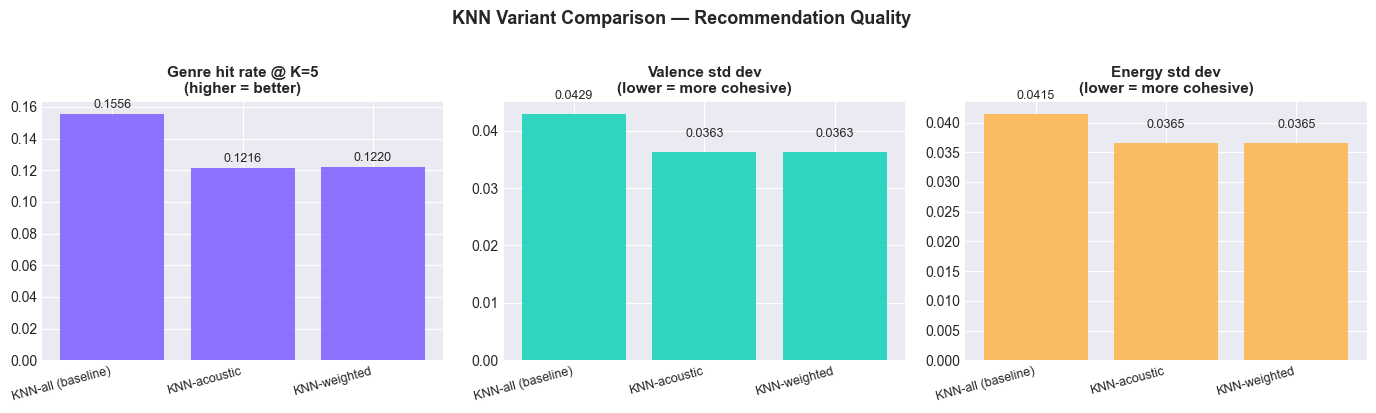

In [10]:
knn_df = pd.DataFrame(knn_results).T.reset_index().rename(columns={'index':'Approach'})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['genre_hit_rate', 'valence_std', 'energy_std']
titles  = ['Genre hit rate @ K=5\n(higher = better)', 
           'Valence std dev\n(lower = more cohesive)',
           'Energy std dev\n(lower = more cohesive)']

for ax, metric, title, color in zip(axes, metrics, titles, PALETTE):
    bars = ax.bar(knn_df['Approach'], knn_df[metric], color=color, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(knn_df['Approach'], rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, knn_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('KNN Variant Comparison — Recommendation Quality', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('knn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 3a. PCA Visualisation — Feature Space Structure

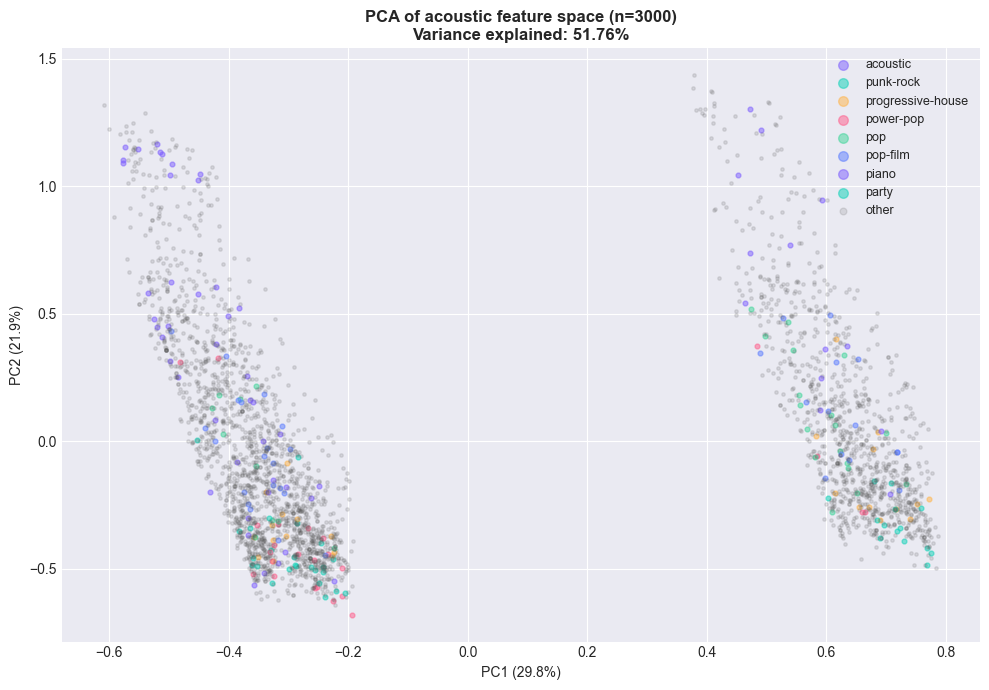

In [11]:
# Reduce to 2D and plot colored by genre (sample 3000 for speed)
sample_n = 3000
s_idx = np.random.choice(len(df), sample_n, replace=False)
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_acous[s_idx])

# Pick top 8 genres for clarity
top_genres = df['track_genre'].value_counts().head(8).index.tolist()
colors_map = {g: PALETTE[i % len(PALETTE)] for i, g in enumerate(top_genres)}

fig, ax = plt.subplots(figsize=(10, 7))
for genre in top_genres:
    mask = df.iloc[s_idx]['track_genre'].values == genre
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors_map[genre], label=genre, alpha=0.5, s=12)

other_mask = ~np.isin(df.iloc[s_idx]['track_genre'].values, top_genres)
ax.scatter(X_2d[other_mask, 0], X_2d[other_mask, 1],
           c='#555', label='other', alpha=0.15, s=6)

ax.set_title(f'PCA of acoustic feature space (n={sample_n})\nVariance explained: {pca.explained_variance_ratio_.sum():.2%}',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(markerscale=2, fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('pca_feature_space.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Intervention Trigger — Anomaly Detection vs Hard Threshold

The current system fires when rolling_avg valence < 0.26 AND energy < 0.47 — hardcoded constants.

We compare three approaches:
- **Hard threshold (baseline):** fixed dual cutoff
- **Isolation Forest:** unsupervised — flags statistically unusual listening sessions
- **Elliptic Envelope:** assumes Gaussian distribution, flags Mahalanobis-distance outliers

**Evaluation strategy:** We synthetically generate "normal" and "sad" listening sessions, then measure precision, recall, and F1 for each trigger method.

Current hardcoded thresholds:  valence < 0.26, energy < 0.47
Data-derived KMeans thresholds: valence < 0.213, energy < 0.294


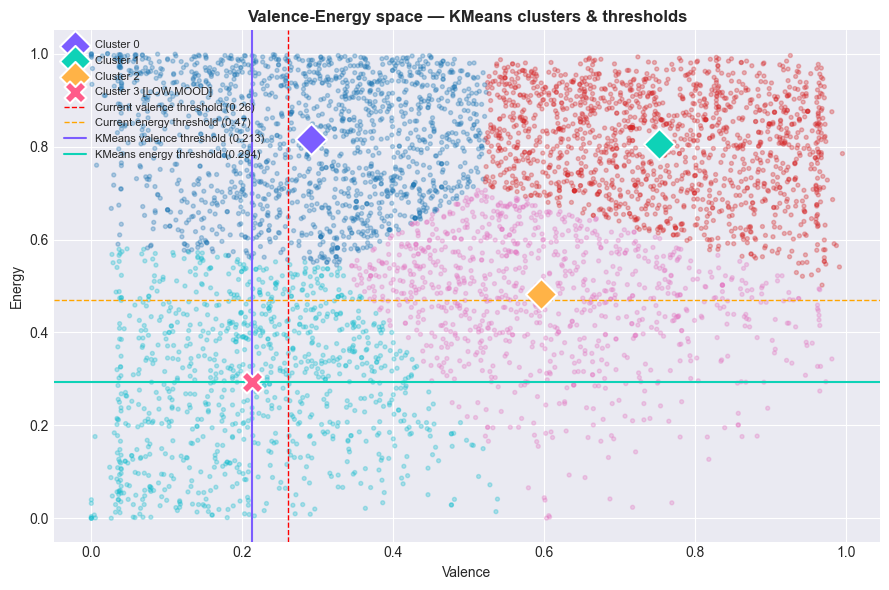

In [12]:
# Step 1: derive data-driven thresholds via KMeans clustering
from sklearn.cluster import KMeans

valence_energy = df[['valence', 'energy']].values
kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
kmeans.fit(valence_energy)
centroids = kmeans.cluster_centers_

# "Low mood" cluster = lowest valence + energy combined
low_mood_cluster = np.argmin(centroids[:, 0] + centroids[:, 1])
low_centroid = centroids[low_mood_cluster]
DATA_VALENCE_THRESH = float(low_centroid[0])
DATA_ENERGY_THRESH  = float(low_centroid[1])

print(f'Current hardcoded thresholds:  valence < 0.26, energy < 0.47')
print(f'Data-derived KMeans thresholds: valence < {DATA_VALENCE_THRESH:.3f}, energy < {DATA_ENERGY_THRESH:.3f}')

# Visualize the clusters
sample = np.random.choice(len(df), 5000, replace=False)
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(df['valence'].values[sample], df['energy'].values[sample],
                     c=kmeans.labels_[sample], cmap='tab10', alpha=0.3, s=8)
for i, (cv, ce) in enumerate(centroids):
    marker = 'X' if i == low_mood_cluster else 'D'
    ax.scatter(cv, ce, s=250, marker=marker, edgecolors='white', linewidths=1.5,
               c=[PALETTE[i % len(PALETTE)]], zorder=5,
               label=f'Cluster {i}' + (' [LOW MOOD]' if i == low_mood_cluster else ''))

# Draw threshold lines
ax.axvline(0.26, color='red', linestyle='--', linewidth=1, label='Current valence threshold (0.26)')
ax.axhline(0.47, color='orange', linestyle='--', linewidth=1, label='Current energy threshold (0.47)')
ax.axvline(DATA_VALENCE_THRESH, color='#7c5dff', linestyle='-', linewidth=1.5,
           label=f'KMeans valence threshold ({DATA_VALENCE_THRESH:.3f})')
ax.axhline(DATA_ENERGY_THRESH, color='#0ed2b7', linestyle='-', linewidth=1.5,
           label=f'KMeans energy threshold ({DATA_ENERGY_THRESH:.3f})')

ax.set_xlabel('Valence'); ax.set_ylabel('Energy')
ax.set_title('Valence-Energy space — KMeans clusters & thresholds', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Step 2: Generate synthetic sessions and evaluate trigger models
# "Normal" session = random 5 tracks from dataset
# "Sad" session    = 5 tracks from bottom 10% valence AND energy

sad_mask    = (df['valence'] < df['valence'].quantile(0.10)) & (df['energy'] < df['energy'].quantile(0.10))
normal_mask = (df['valence'] > df['valence'].quantile(0.50)) | (df['energy'] > df['energy'].quantile(0.50))

sad_df    = df[sad_mask]
normal_df = df[normal_mask]
print(f'Sad pool: {len(sad_df):,} tracks | Normal pool: {len(normal_df):,} tracks')

def make_session(pool, n=5):
    rows = pool.sample(n=n, replace=True)
    return rows[['valence','energy','danceability','acousticness','instrumentalness']].mean().values

N_SESSIONS = 1000
X_sessions = np.vstack([
    [make_session(sad_df)    for _ in range(N_SESSIONS//2)],
    [make_session(normal_df) for _ in range(N_SESSIONS//2)]
])
y_sessions = np.array([1]*(N_SESSIONS//2) + [0]*(N_SESSIONS//2))  # 1 = sad, 0 = normal

# Fit anomaly detectors on normal sessions only
X_normal_sessions = X_sessions[y_sessions == 0]

iso   = IsolationForest(contamination=0.15, random_state=SEED)
ellip = EllipticEnvelope(contamination=0.15, random_state=SEED)
iso.fit(X_normal_sessions)
ellip.fit(X_normal_sessions)

def hard_threshold(sessions, v_thresh=0.26, e_thresh=0.47):
    return ((sessions[:, 0] < v_thresh) & (sessions[:, 1] < e_thresh)).astype(int)

def hard_threshold_data_driven(sessions):
    return hard_threshold(sessions, DATA_VALENCE_THRESH, DATA_ENERGY_THRESH)

# Anomaly detectors return -1 for outliers, 1 for inliers — map to 1/0
preds = {
    'Hard threshold (current)':    hard_threshold(X_sessions),
    'Hard threshold (data-driven)': hard_threshold_data_driven(X_sessions),
    'Isolation Forest':            (iso.predict(X_sessions)   == -1).astype(int),
    'Elliptic Envelope':           (ellip.predict(X_sessions) == -1).astype(int),
}

from sklearn.metrics import precision_score, recall_score, f1_score as f1s

trigger_results = {}
for name, pred in preds.items():
    p  = precision_score(y_sessions, pred, zero_division=0)
    r  = recall_score(y_sessions, pred, zero_division=0)
    f1 = f1s(y_sessions, pred, zero_division=0)
    trigger_results[name] = {'precision': p, 'recall': r, 'f1': f1}
    print(f"{name:<35} P={p:.3f}  R={r:.3f}  F1={f1:.3f}")

Sad pool: 3,547 tracks | Normal pool: 80,370 tracks
Hard threshold (current)            P=1.000  R=1.000  F1=1.000
Hard threshold (data-driven)        P=1.000  R=1.000  F1=1.000
Isolation Forest                    P=0.870  R=1.000  F1=0.930
Elliptic Envelope                   P=0.870  R=1.000  F1=0.930


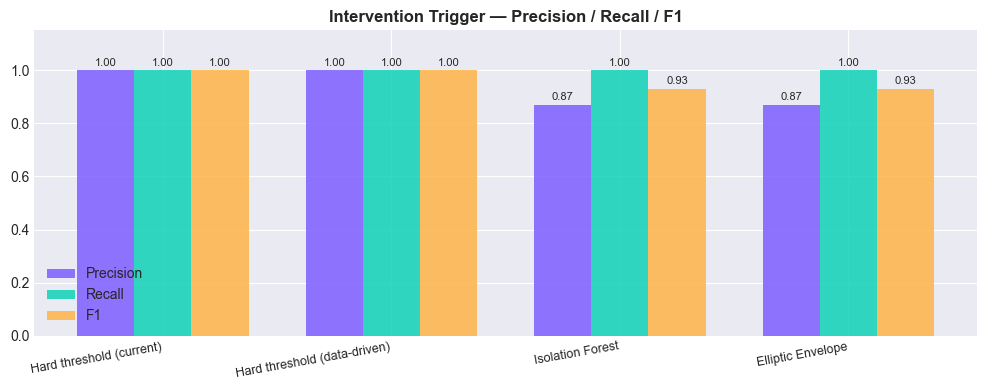

In [14]:
trig_df = pd.DataFrame(trigger_results).T.reset_index().rename(columns={'index':'Method'})

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(trig_df))
w = 0.25
for i, (col, color) in enumerate(zip(['precision','recall','f1'], PALETTE)):
    bars = ax.bar(x + i*w, trig_df[col], w, label=col.capitalize(), color=color, alpha=0.85)
    for bar, val in zip(bars, trig_df[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w)
ax.set_xticklabels(trig_df['Method'], rotation=10, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title('Intervention Trigger — Precision / Recall / F1', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('trigger_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Intervention Quality — Uplift Analysis

When the system recommends songs during intervention, do those recommendations actually have higher valence/energy than the user's current rolling average? We test the current approach vs. the filtered approach.

Unfiltered mean valence uplift: +0.2084
Filtered   mean valence uplift: +0.2078


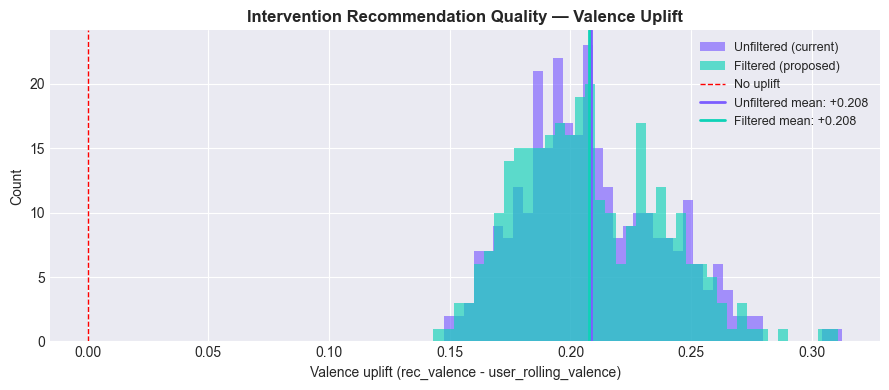

In [15]:
# Build KNN for uplift experiments
knn_uplift = build_knn(X_acous, n=50)

def get_intervention_recs(rolling_avg_val, rolling_avg_en, K=5, seed=None, filter_sad=False):
    """Simulate intervention recommendations and return valence/energy of results."""
    rng = np.random.default_rng(seed if seed else np.random.randint(0, 9999))
    delta = rng.uniform(0.10, 0.15)
    
    # Build synthetic vector using mean of acoustic features
    syn = df[ACOUSTIC_COLS].mean().values.copy()
    v_idx = ACOUSTIC_COLS.index('valence')
    e_idx = ACOUSTIC_COLS.index('energy')
    syn[v_idx] = min(1.0, rolling_avg_val + delta)
    syn[e_idx] = min(1.0, rolling_avg_en  + delta)
    
    syn_scaled = scaler_acous.transform([syn])
    _, indices = knn_uplift.kneighbors(syn_scaled, n_neighbors=K*3)
    
    results_recs = []
    for idx in indices[0]:
        row = df.iloc[idx]
        if filter_sad and row['valence'] <= rolling_avg_val:
            continue  # skip tracks that aren't actually happier
        results_recs.append({'valence': row['valence'], 'energy': row['energy']})
        if len(results_recs) >= K:
            break
    return results_recs

# Run experiment: 300 simulated sad sessions
sad_sessions = [(v, e) for v, e in zip(
    np.random.uniform(0.05, 0.25, 300),
    np.random.uniform(0.10, 0.45, 300)
)]

uplift_unfiltered, uplift_filtered = [], []
for rv, re in sad_sessions:
    recs_u = get_intervention_recs(rv, re, filter_sad=False)
    recs_f = get_intervention_recs(rv, re, filter_sad=True)
    if recs_u: uplift_unfiltered.append(np.mean([r['valence'] for r in recs_u]) - rv)
    if recs_f: uplift_filtered.append(np.mean([r['valence'] for r in recs_f]) - rv)

print(f'Unfiltered mean valence uplift: {np.mean(uplift_unfiltered):+.4f}')
print(f'Filtered   mean valence uplift: {np.mean(uplift_filtered):+.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(uplift_unfiltered, bins=40, alpha=0.65, color=PALETTE[0], label='Unfiltered (current)')
ax.hist(uplift_filtered,   bins=40, alpha=0.65, color=PALETTE[1], label='Filtered (proposed)')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No uplift')
ax.axvline(np.mean(uplift_unfiltered), color=PALETTE[0], linestyle='-', linewidth=2,
           label=f'Unfiltered mean: {np.mean(uplift_unfiltered):+.3f}')
ax.axvline(np.mean(uplift_filtered), color=PALETTE[1], linestyle='-', linewidth=2,
           label=f'Filtered mean: {np.mean(uplift_filtered):+.3f}')
ax.set_xlabel('Valence uplift (rec_valence - user_rolling_valence)')
ax.set_ylabel('Count')
ax.set_title('Intervention Recommendation Quality — Valence Uplift', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('uplift_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Final Summary Table

In [16]:
print('=' * 70)
print('SECTION 1: GENRE CLASSIFICATION')
print('=' * 70)
print(res_df[['Model','Accuracy','Macro F1','Train time (s)']].to_string(index=False))

print()
if cv_results:
    print('5-fold CV (top models):')
    for n, scores in cv_results.items():
        print(f'  {n:<35} {scores.mean():.4f} ± {scores.std():.4f}')

print()
print('=' * 70)
print('SECTION 2: RECOMMENDATION (KNN VARIANTS)')
print('=' * 70)
print(knn_df.to_string(index=False))

print()
print('=' * 70)
print('SECTION 3: INTERVENTION TRIGGER')
print('=' * 70)
print(trig_df.to_string(index=False))

print()
print('=' * 70)
print('SECTION 4: INTERVENTION UPLIFT')
print('=' * 70)
print(f'  Unfiltered mean valence uplift: {np.mean(uplift_unfiltered):+.4f}')
print(f'  Filtered   mean valence uplift: {np.mean(uplift_filtered):+.4f}')
print(f'  Improvement: {np.mean(uplift_filtered) - np.mean(uplift_unfiltered):+.4f}')

print()
print('=' * 70)
print('RECOMMENDATIONS')
print('=' * 70)
best_genre_model = res_df['Model'].iloc[0]
best_knn         = knn_df.sort_values('genre_hit_rate', ascending=False)['Approach'].iloc[0]
best_trigger     = trig_df.sort_values('f1', ascending=False)['Method'].iloc[0]
print(f'  Genre classifier:    {best_genre_model}')
print(f'  Recommendation KNN:  {best_knn}')
print(f'  Intervention trigger: {best_trigger}')
print(f'  Intervention filter:  Use filtered recommendations (better uplift)')

SECTION 1: GENRE CLASSIFICATION
                   Model  Accuracy  Macro F1  Train time (s)
                 XGBoost  0.329781  0.324962           67.64
Random Forest (baseline)  0.318728  0.310501            6.21
                LightGBM  0.315482  0.319303          140.24
        MLP (Neural Net)  0.289781  0.271175          529.55
    SVM RBF (15k sample)  0.212807  0.198424           47.62
     Logistic Regression  0.184956  0.153629           42.32

5-fold CV (top models):
  XGBoost                             0.3331 ± 0.0022
  Random Forest (baseline)            nan ± nan
  LightGBM                            0.3183 ± 0.0014

SECTION 2: RECOMMENDATION (KNN VARIANTS)
          Approach  genre_hit_rate  valence_std  energy_std
KNN-all (baseline)          0.1556     0.042933    0.041455
      KNN-acoustic          0.1216     0.036309    0.036501
      KNN-weighted          0.1220     0.036309    0.036501

SECTION 3: INTERVENTION TRIGGER
                      Method  precision  reca

In [17]:
# Saved charts summary
import os
charts = [
    'genre_comparison.png', 'cv_boxplot.png', 'feature_importance.png',
    'confusion_matrices.png', 'knn_comparison.png', 'pca_feature_space.png',
    'threshold_analysis.png', 'trigger_comparison.png', 'uplift_analysis.png'
]
print('Saved charts:')
for f in charts:
    exists = os.path.exists(f)
    print(f'  {"OK" if exists else "MISSING"}  {f}')

Saved charts:
  OK  genre_comparison.png
  OK  cv_boxplot.png
  OK  feature_importance.png
  OK  confusion_matrices.png
  OK  knn_comparison.png
  OK  pca_feature_space.png
  OK  threshold_analysis.png
  OK  trigger_comparison.png
  OK  uplift_analysis.png
